In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
df=pd.read_csv('/content/netflix_titles.csv')

In [8]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,1-Jul-19,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,1-Nov-19,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [22]:
df['rating'].value_counts()

,count
rating,
TV-MA,7310
TV-14,5246
TV-PG,1908
R,1582
PG-13,998
PG,607
TV-Y7,529
TV-G,459
TV-Y,406


In [23]:
df = df[~df['rating'].str.contains('min', na=False)]

In [24]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [25]:
df['rating'].value_counts()

,count
rating,
TV-MA,7310
TV-14,5246
TV-PG,1908
R,1582
PG-13,998
PG,607
TV-Y7,529
TV-G,459
TV-Y,406


Find out how content addition trends differ between Movies and TV Shows over time.

In [26]:


df['date_added']=pd.to_datetime(df['date_added'],format='mixed',errors='coerce')

df['year_added']=df['date_added'].dt.year

In [27]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,genres_split
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,International TV Shows
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,TV Dramas


In [28]:
##yearly difference in table format
yearly=df.groupby(['year_added','type']).size().unstack()
yearly = yearly.fillna(0)
yearly = yearly.astype(int)
yearly['differnce']=yearly['Movie']-yearly['TV Show']

print(yearly)


type        Movie  TV Show  differnce
year_added                           
2008.0          3        1          2
2009.0          3        0          3
2010.0          2        0          2
2011.0         19        0         19
2012.0          4        0          4
2013.0         10       13         -3
2014.0         26       11         15
2015.0         98       54         44
2016.0        456      398         58
2017.0       1750      840        910
2018.0       2738      931       1807
2019.0       3108     1399       1709
2020.0       2824     1338       1486
2021.0       2144     1124       1020


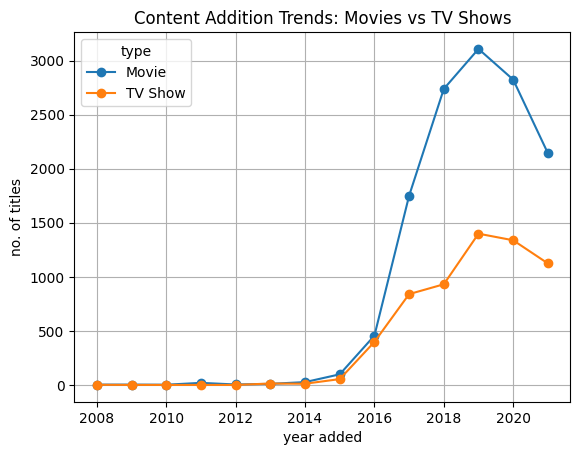

In [29]:
##now the plot
yearly[['Movie','TV Show']].plot(kind='line', marker='o')
plt.xlabel("year added")
plt.ylabel("no. of titles")
plt.title("Content Addition Trends: Movies vs TV Shows")
plt.grid(True)
plt.show()

Find out how Netflix’s global content strategy varies across country, content type, and audience rating.

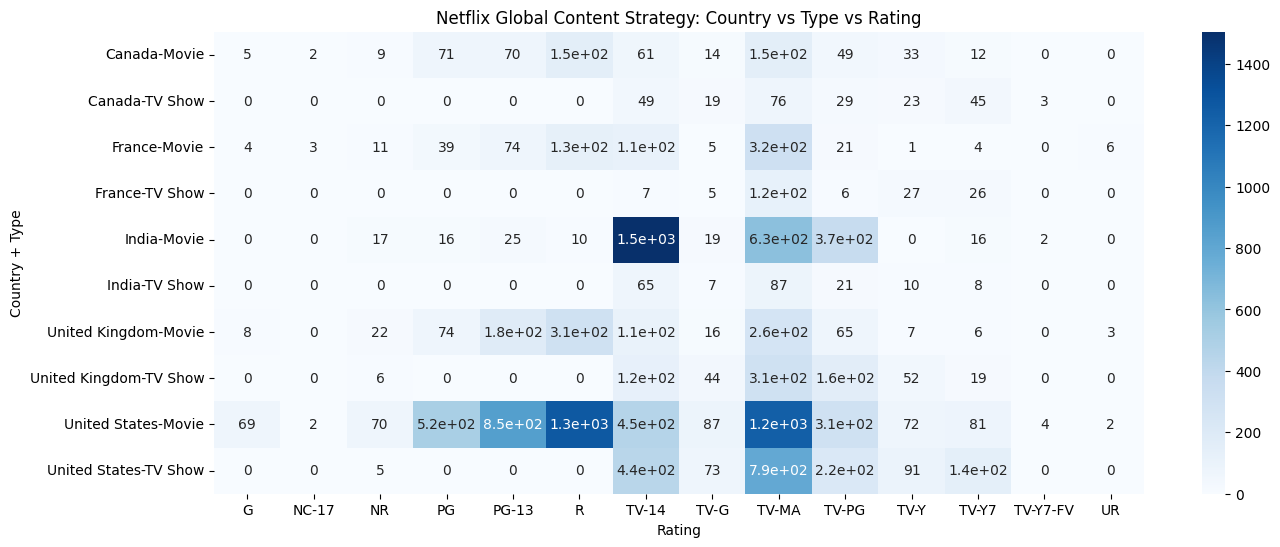

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = df.copy()

#  Clean country column
df['country'] = df['country'].str.split(', ')
df = df.explode('country')

# Take top 5 countries
top_countries = df['country'].value_counts().head(5).index
df_top = df[df['country'].isin(top_countries)]

#  Group data (MULTIVARIATE)
heat = df_top.groupby(['country','type','rating']).size().unstack(fill_value=0)

#  Plot heatmap
plt.figure(figsize=(15,6))
sns.heatmap(heat, annot=True, cmap="Blues")

plt.title("Netflix Global Content Strategy: Country vs Type vs Rating")
plt.xlabel("Rating")
plt.ylabel("Country + Type")

plt.show()

# #7

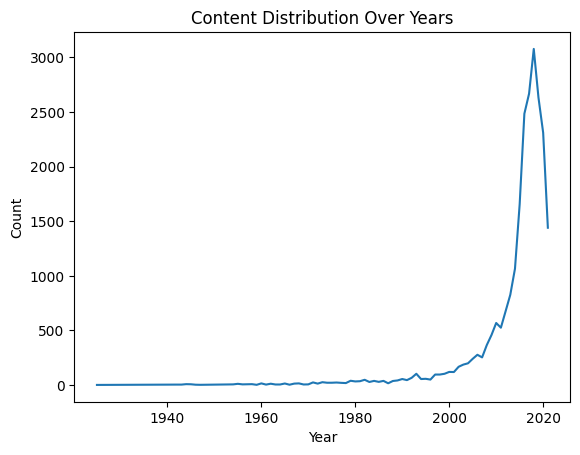

In [31]:
#How is Netflix content distributed across different release years?
year_count = df['release_year'].value_counts().sort_index()

plt.figure()
year_count.plot()
plt.title("Content Distribution Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

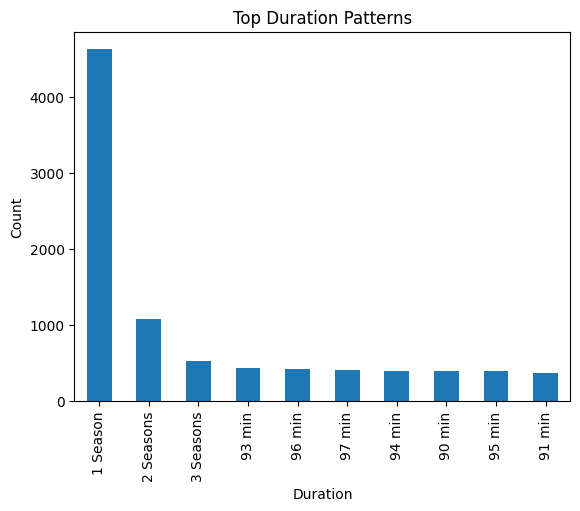

In [32]:
##What patterns exist in the duration of Netflix content?

duration_count = df['duration'].value_counts().head(10)

plt.figure()
duration_count.plot(kind='bar')
plt.title("Top Duration Patterns")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.show()

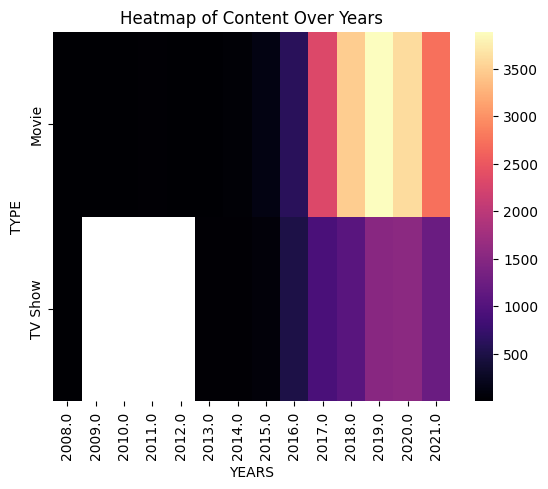

In [33]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')
df['year_added'] = df['date_added'].dt.year
pivot = df.pivot_table(index='type', columns='year_added', aggfunc='size')
sns.heatmap(pivot, cmap='magma')
plt.title("Heatmap of Content Over Years")
plt.xlabel("YEARS")
plt.ylabel("TYPE")
plt.show()
plt.show()

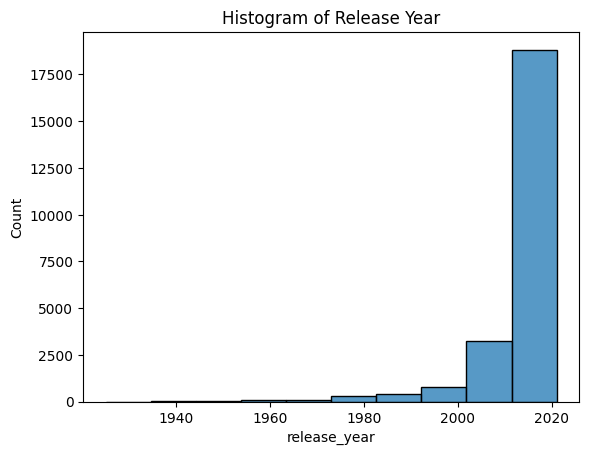

In [34]:
#.Visualize how many movies and shows were released in different years
sns.histplot(df['release_year'], bins=10)
plt.title("Histogram of Release Year")
plt.show()

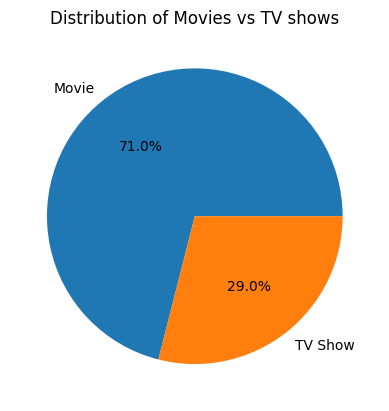

In [35]:
#what is the  distribution of content types (Movies and TV shows) on Netfix.

import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Movies vs TV shows')
plt.ylabel('')
plt.show()

In [36]:
# Which directors have the most Netflix titles in the dataset .

director_count = df['director'].value_counts()
print(director_count.head(5))

director
Youssef Chahine        46
Cathy Garcia-Molina    37
Martin Scorsese        36
Lars von Trier         33
Steven Spielberg       32
Name: count, dtype: int64


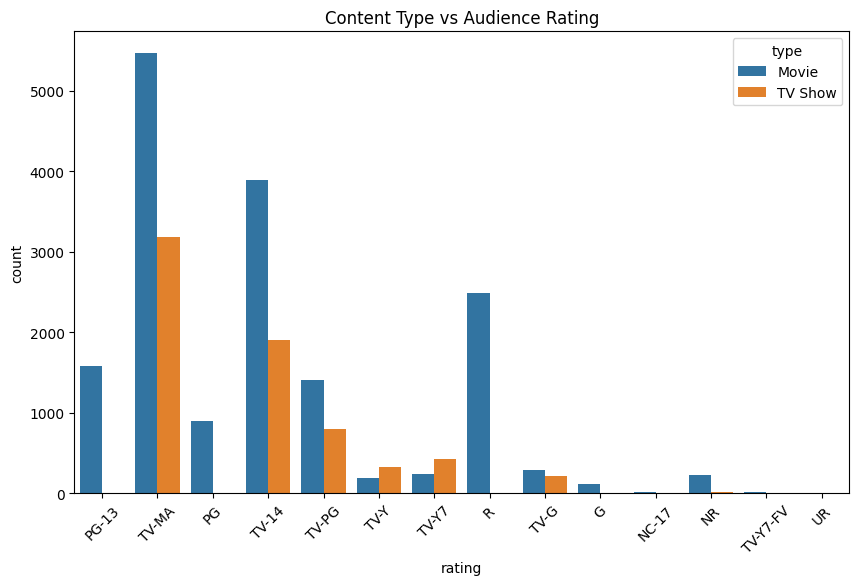

In [37]:
#How does the distribution of content type (Movies vs TV Shows) vary across different audience ratings on Netflix?
df[['type','rating']].head(10)
df = df.dropna(subset=['rating'])
plt.figure(figsize=(10,6))
sns.countplot(x='rating', hue='type', data=df)
plt.xticks(rotation=45)
plt.title('Content Type vs Audience Rating')
plt.show()

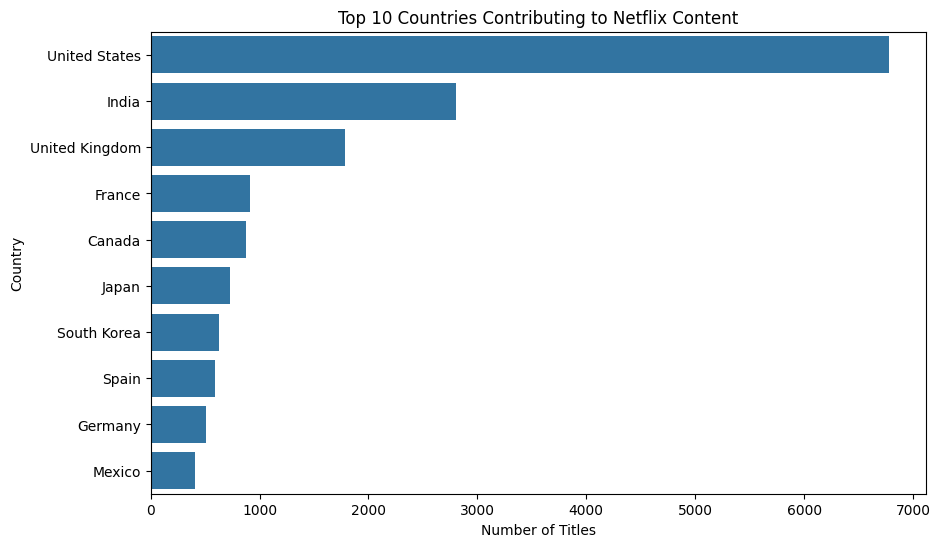

In [38]:
#Which countries contribute the most content to Netflix, and what is the distribution among the top 10 contributors
top10 = df['country'].dropna().str.split(',').explode().str.strip().value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index)
plt.title('Top 10 Countries Contributing to Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

<Axes: xlabel='type', ylabel='count'>

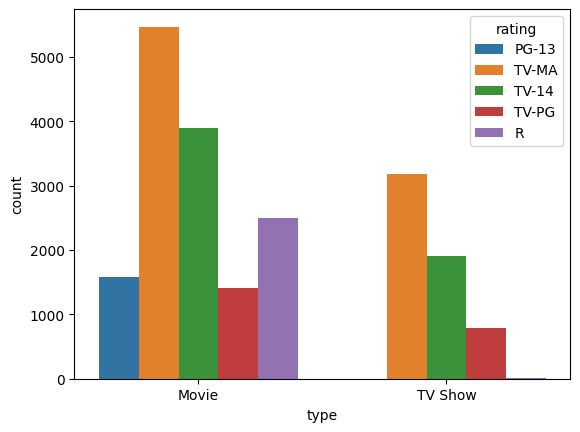

In [39]:
#Distribution of audience ratings across content types.

top_ratings = df['rating'].value_counts().head(5).index

filtered_df = df[df['rating'].isin(top_ratings)]

sns.countplot(
    x='type',
    hue='rating',
    data=filtered_df
)

In [40]:
df['type'].value_counts()

,count
type,
Movie,16868
TV Show,6877
